# N2 · model-based vs model-free 样本效率

> 配套 11.5-L3 · 对比两条路:
> - **model-based**: 从**随机**转移学世界模型 + MPC 规划 (数据便宜, 零专家)
> - **model-free (BC)**: 从**专家** demo 监督学策略 (需专家)
> 看 model-based 怎么用便宜数据换好策略。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import world_model as wm
import toy_env as env   # M11.1 共享 (world_model 已加进 path)
import numpy as np, torch
# 复用 M11.4 的 BC (model-free 对照)
sys.path.insert(0, str(Path.cwd().parents[1] / "robot-data-imitation" / "src"))
import bc_train as bc
print('就绪: world_model (model-based) + bc_train (model-free)')

就绪: world_model (model-based) + bc_train (model-free)


## 1. 两条路在不同数据量下的成功率

In [2]:
torch.manual_seed(0)
sizes = [20, 50, 100, 500, 2000]
mb, mf = [], []
for n in sizes:
    # model-based: n 条随机转移 → 世界模型 → MPC
    S,A,D = wm.make_random_transitions(n=n, seed=0)
    m = wm.build_world_model(); wm.train_world_model(m, S, A, D, epochs=400)
    mb.append(env.eval_policy(wm.mpc_policy_fn(m, n_samples=150, horizon=6), n_episodes=80))
    # model-free: 用约 n 个专家 (state,action) 对做 BC
    Se,Ae = env.make_demos(n=max(2, n//8), seed=0)   # 每条 demo ~8 步, 凑到 ~n 个对
    Se,Ae = Se[:n], Ae[:n]
    mfm = bc.build_bc_policy(); bc.train_bc(mfm, Se, Ae, epochs=300)
    mf.append(env.eval_policy(bc.bc_policy_fn(mfm), n_episodes=80))
    print(f'{n:5d} 样本: model-based(随机) {mb[-1]:.2f} | model-free/BC(专家) {mf[-1]:.2f}')

   20 样本: model-based(随机) 0.82 | model-free/BC(专家) 0.05


   50 样本: model-based(随机) 0.95 | model-free/BC(专家) 0.11


  100 样本: model-based(随机) 0.86 | model-free/BC(专家) 0.57


  500 样本: model-based(随机) 0.86 | model-free/BC(专家) 0.90


 2000 样本: model-based(随机) 0.86 | model-free/BC(专家) 0.95


## 2. 样本效率曲线

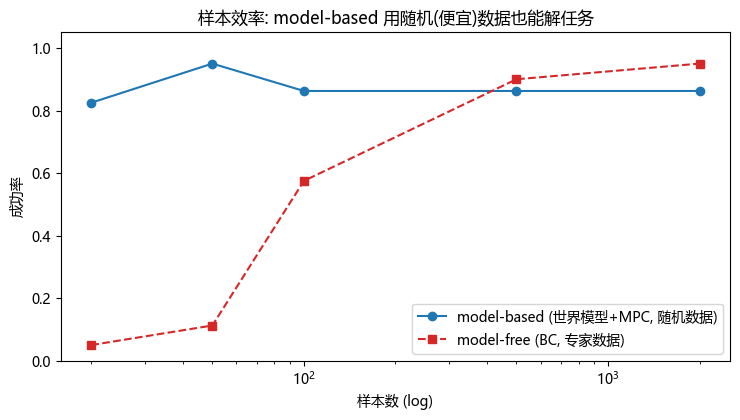

model-based(随机): {20: 0.82, 50: 0.95, 100: 0.86, 500: 0.86, 2000: 0.86}
model-free(专家):  {20: 0.05, 50: 0.11, 100: 0.57, 500: 0.9, 2000: 0.95}
→ 关键: model-based 的数据是随机探索(免费); model-free 的数据是专家(贵)。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
fig, ax = plt.subplots(figsize=(7.5,4.3))
ax.plot(sizes, mb, 'o-', color='C0', label='model-based (世界模型+MPC, 随机数据)')
ax.plot(sizes, mf, 's--', color='C3', label='model-free (BC, 专家数据)')
ax.set_xscale('log'); ax.set_xlabel('样本数 (log)'); ax.set_ylabel('成功率'); ax.set_ylim(0,1.05)
ax.legend(); ax.set_title('样本效率: model-based 用随机(便宜)数据也能解任务')
plt.tight_layout(); plt.show()
print('model-based(随机):', {n:round(v,2) for n,v in zip(sizes,mb)})
print('model-free(专家): ', {n:round(v,2) for n,v in zip(sizes,mf)})
print('→ 关键: model-based 的数据是随机探索(免费); model-free 的数据是专家(贵)。')

## 3. 解读 (接 L3 + 9.4)

In [4]:
lines = [
 'model-based vs model-free (L3):',
 '  model-based: 学世界模型(随机数据可) + 规划 -> 数据便宜, 样本效率高',
 '               但 世界模型不准->规划歪 (model bias); 复杂动态难学',
 '  model-free:  直接学策略 -> 简单通用; 但 BC 需专家 / RL 需大量交互',
 '',
 '关键差异不只是成功率曲线, 更是数据从哪来:',
 '  - model-based 从随机探索学 (本 toy reach 动态好学 -> MPC 高成功)',
 '  - model-free 从专家 demo 学 (数据贵)',
 '  -> 机器人(交互贵)偏好 model-based 用便宜数据换策略; 复杂任务世界模型难学, 常混合。',
]
print(chr(10).join(lines))

model-based vs model-free (L3):
  model-based: 学世界模型(随机数据可) + 规划 -> 数据便宜, 样本效率高
               但 世界模型不准->规划歪 (model bias); 复杂动态难学
  model-free:  直接学策略 -> 简单通用; 但 BC 需专家 / RL 需大量交互

关键差异不只是成功率曲线, 更是数据从哪来:
  - model-based 从随机探索学 (本 toy reach 动态好学 -> MPC 高成功)
  - model-free 从专家 demo 学 (数据贵)
  -> 机器人(交互贵)偏好 model-based 用便宜数据换策略; 复杂任务世界模型难学, 常混合。


## 4. 反思 (11.5 收口)

你对比了两条路的样本效率。带走:
- **model-based**: 世界模型(随机数据)+规划, 数据便宜、样本效率高; 但靠世界模型准 (复杂动态难学)。
- **model-free (BC)**: 直接学策略, 简单; 但需专家 demo (贵)。
- 核心差异是**数据从哪来**: 随机探索(免费) vs 专家(贵); 机器人(交互贵)偏好 model-based, 常混合。

> **M11.5 收口**: 世界模型学转移→想象→规划(MPC); 先学想象再学行动; model-based 省交互; 视频模型=图像世界模型 (接 M13)。
> **交棒 M11.6「sim2real-isaaclab」**: 从想象的世界到**仿真**的世界 —— IsaacLab 仿真训练 + sim2real gap (你碰过 IsaacLab!)。下一专题 `sim2real-isaaclab`。